**Cell 0 — Imports + config**

In [ ]:

# install pytorch (pick the one matching your CUDA; here is CPU example)
!pip install torch torchvision torchaudio

# spikingjelly (activation_based)
!pip install spikingjelly

!pip install numpy pandas scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 26.0 MB/s eta 0:00:00


In [ ]:
import os, time, math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import spikingjelly

from spikingjelly.activation_based import neuron, surrogate, functional

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


In [ ]:
import torch
import spikingjelly
print(torch.__version__)


2.9.0+cu126


**Notebook: E1 End-to-End (ANN + PatchTST + SNN with SpikingJelly LIF)**

**Cell 1 — Metrics (RMSE/MAE/SMAPE)**

In [ ]:
def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae_np(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))

def smape_np(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(200.0 * np.mean(np.abs(y_pred - y_true) / denom))

@torch.no_grad()
def eval_metrics(y_true_t, y_pred_t):
    y_true = y_true_t.detach().cpu().numpy()
    y_pred = y_pred_t.detach().cpu().numpy()
    return {
        "rmse": rmse_np(y_true, y_pred),
        "mae": mae_np(y_true, y_pred),
        "smape": smape_np(y_true, y_pred)
    }


Cell 2 — Dataset paths + loader

Update only the time/target columns if needed.
I’ll make a robust loader that guesses time + target if you didn’t set them.

In [ ]:
import pandas as pd

DATASETS = {
    "SR": {
        "path": "Palestine-Solar.csv",
        "time_col": None,   # auto
        "target_col": None, # auto
    },
    "WS": {
        "path": "Palestine-wind.csv",
        "time_col": None,
        "target_col": None,
    },
    "WP": {
        "path": "Turky-Wind-power-Turbine.csv",
        "time_col": None,
        "target_col": None,
    },
    "EC": {
        "path": "Moroco-power-consumption.csv",
        "time_col": None,
        "target_col": None,
    },
}

def _guess_time_col(df: pd.DataFrame) -> str:
    # common names
    for c in ["date", "Date", "datetime", "Datetime", "timestamp", "Timestamp", "time", "Time"]:
        if c in df.columns:
            return c
    # fallback: first column
    return df.columns[0]

def _guess_target_col(df: pd.DataFrame) -> str:
    # prefer known patterns
    preferred = {"target", "y", "power", "ghi", "load", "consumption", "windspeed", "wind_speed"}
    cand = [c for c in df.columns if c.lower() in preferred]
    if cand:
        return cand[0]

    # otherwise pick last numeric column
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        raise ValueError("No numeric columns found for target.")
    return num_cols[-1]

def load_df(task_id: str):
    cfg = DATASETS[task_id]
    path = cfg["path"]
    df = pd.read_csv(path)

    time_col = cfg["time_col"] or _guess_time_col(df)
    target_col = cfg["target_col"] or _guess_target_col(df)

    # parse datetime if possible
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

    # keep numeric features only (except time)
    feat_cols = [c for c in df.columns if c != time_col and pd.api.types.is_numeric_dtype(df[c])]
    if target_col not in feat_cols:
        raise ValueError(f"Target col '{target_col}' is not numeric or not found among numeric features.")

    df = df[[time_col] + feat_cols].copy()

    # --- requested prints ---
    print(f"\n=== Dataset {task_id} ===")
    print(f"Path: {path}")
    print(f"Time column: {time_col}")
    print(f"Target variable: {target_col}")
    #print("First 3 rows:")
    #print(df.head(3))
    # ------------------------

    return df, {"time_col": time_col, "target_col": target_col, "feat_cols": feat_cols}

if __name__ == "__main__":
    # Load all datasets and print target + head(3) for each
    loaded = {}
    meta = {}

    for task_id in DATASETS.keys():
        df, info = load_df(task_id)
        loaded[task_id] = df
        meta[task_id] = info

    # Optional: quick summary at the end
    print("\n=== Summary ===")
    for task_id, info in meta.items():
        print(f"{task_id}: time_col={info['time_col']}, target_col={info['target_col']}, n_features={len(info['feat_cols'])}")



=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI

=== Dataset WS ===
Path: Palestine-wind.csv
Time column: date
Target variable: Wind Speed

=== Dataset WP ===
Path: Turky-Wind-power-Turbine.csv
Time column: date
Target variable: LV ActivePower (kW)

=== Dataset EC ===
Path: Moroco-power-consumption.csv
Time column: Datetime
Target variable: WindSpeed

=== Summary ===
SR: time_col=date, target_col=GHI, n_features=9
WS: time_col=date, target_col=Wind Speed, n_features=7
WP: time_col=date, target_col=LV ActivePower (kW), n_features=3
EC: time_col=Datetime, target_col=WindSpeed, n_features=4


**Cell 3 — Windowing + splits + standardization**

In [ ]:
def make_supervised(df, time_col, target_col, lookback, horizons, add_calendar=True):
    feat_cols = [c for c in df.columns if c != time_col]
    X_raw = df[feat_cols].values.astype(np.float32)

    # optional calendar features
    if add_calendar:
        t = df[time_col]
        cal = np.stack([
            t.dt.hour.fillna(0).values,
            t.dt.dayofweek.fillna(0).values,
            t.dt.month.fillna(0).values,
        ], axis=1).astype(np.float32)
        cal[:,0] /= 23.0
        cal[:,1] /= 6.0
        cal[:,2] /= 12.0
        X_raw = np.concatenate([X_raw, cal], axis=1)

    # target is the specific column (before calendar features!)
    target_idx = feat_cols.index(target_col)

    H = len(horizons)
    L = lookback
    N = len(X_raw)

    X = []
    Y = []
    max_h = max(horizons)
    for i in range(L, N - max_h):
        xw = X_raw[i-L:i]  # (L, F)
        y = []
        for h in horizons:
            y.append(df[target_col].values[i + h].astype(np.float32))
        X.append(xw)
        Y.append(y)

    X = np.stack(X, axis=0)  # (Nw, L, F)
    Y = np.stack(Y, axis=0)  # (Nw, H)
    return X, Y

def chronological_split(X, Y, train_ratio=0.7, val_ratio=0.1):
    n = len(X)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    Xtr, Ytr = X[:n_train], Y[:n_train]
    Xva, Yva = X[n_train:n_train+n_val], Y[n_train:n_train+n_val]
    Xte, Yte = X[n_train+n_val:], Y[n_train+n_val:]
    return (Xtr,Ytr),(Xva,Yva),(Xte,Yte)

def standardize_fit_transform(Xtr, Xva, Xte):
    mu = Xtr.mean(axis=(0,1), keepdims=True)
    sd = Xtr.std(axis=(0,1), keepdims=True) + 1e-6
    return (Xtr-mu)/sd, (Xva-mu)/sd, (Xte-mu)/sd, (mu,sd)

class WindowDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


**ANN baselines**

In [ ]:
class MLPBaseline(nn.Module):
    def __init__(self, lookback, F, K, hidden=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(lookback * F, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, K),
        )

    def forward(self, x):
        return self.net(x)


class RNNBaseline(nn.Module):
    def __init__(self, kind, F, K, hidden=128, layers=2, dropout=0.1):
        super().__init__()
        RNN = nn.LSTM if kind == "lstm" else nn.GRU
        self.rnn = RNN(
            input_size=F, hidden_size=hidden,
            num_layers=layers, batch_first=True,
            dropout=dropout if layers > 1 else 0.0
        )
        self.head = nn.Linear(hidden, K)

    def forward(self, x):
        out, _ = self.rnn(x)           # (B,L,H)
        return self.head(out[:, -1])   # last step


class TCNBaseline(nn.Module):
    def __init__(self, F, K, channels=128, levels=3, k=3, dropout=0.1):
        super().__init__()
        layers = []
        in_ch = F
        for i in range(levels):
            dilation = 2 ** i
            pad = (k - 1) * dilation
            layers += [
                nn.Conv1d(in_ch, channels, kernel_size=k, dilation=dilation, padding=pad),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_ch = channels
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(channels, K)

    def forward(self, x):
        # x: (B,L,F) -> (B,F,L)
        z = x.transpose(1, 2)
        z = self.net(z)
        z = z[:, :, -1]      # last time step
        return self.head(z)


class PatchTST(nn.Module):
    """
    Simple PatchTST-style baseline: patchify -> linear embed -> Transformer encoder -> head
    (Not the full official PatchTST, but a strong TSFormer-style baseline.)
    """
    def __init__(self, F, K, patch_len=16, stride=8, d_model=128, nhead=4, layers=3, dropout=0.1):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride

        self.proj = nn.Linear(patch_len * F, d_model)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            dropout=dropout, batch_first=True, activation="gelu", norm_first=True
        )
        self.tf = nn.TransformerEncoder(enc, num_layers=layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, K))

    def patchify(self, x):
        # x: (B,L,F) -> (B,Np,patch_len,F)
        B, L, F = x.shape
        patches = []
        for s in range(0, L - self.patch_len + 1, self.stride):
            patches.append(x[:, s:s+self.patch_len, :])
        p = torch.stack(patches, dim=1)
        return p

    def forward(self, x):
        p = self.patchify(x)
        B, Np, Pl, F = p.shape
        tok = p.reshape(B, Np, Pl*F)
        z = self.proj(tok)
        h = self.tf(z)
        return self.head(h[:, -1])


**Cell 4 — Training utilities (fixed tensors + RMSE/MAE/SMAPE)**

In [ ]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_total_params(model):
    return sum(p.numel() for p in model.parameters())

def _to_device(x):
    if torch.is_tensor(x):
        return x.to(device)
    return torch.from_numpy(x).to(device)

def train_one_epoch(model, loader, optim):
    model.train()
    crit = nn.MSELoss()
    total = 0.0
    for xb, yb in loader:
        xb = _to_device(xb)
        yb = _to_device(yb)

        optim.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = crit(pred, yb)
        loss.backward()
        optim.step()
        total += loss.item() * xb.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    preds, trues = [], []
    for xb, yb in loader:
        xb = _to_device(xb)
        yb = _to_device(yb)
        pred = model(xb)
        preds.append(pred)
        trues.append(yb)
    preds = torch.cat(preds, dim=0)
    trues = torch.cat(trues, dim=0)
    m = eval_metrics(trues, preds)
    return m["rmse"], m["mae"], m["smape"]

def fit(model, train_loader, val_loader, lr=1e-3, wd=1e-4, max_epochs=30, patience=10):
    optim = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=wd)

    best_rmse = float("inf")
    best_state = None
    best_epoch = 0
    bad = 0
    t0 = time.time()

    for ep in range(1, max_epochs+1):
        _ = train_one_epoch(model, train_loader, optim)
        val_rmse, val_mae, val_smape = eval_model(model, val_loader)

        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = ep
            bad = 0
        else:
            bad += 1

        if bad >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, {
        "best_epoch": best_epoch,
        "best_val_rmse": best_rmse,
        "train_time_sec": time.time() - t0,
        "trainable_params": count_trainable_params(model),
        "total_params": count_total_params(model),
    }


**Cell 5 — LoRA + SpikeLoRA modules (complete)**

In [ ]:
class LoRALinear(nn.Module):
    def __init__(self, base: nn.Linear, r=8, alpha=16, dropout=0.0):
        super().__init__()
        self.base = base
        self.r = r
        self.alpha = alpha
        self.scale = alpha / r
        self.drop = nn.Dropout(dropout)

        in_dim = base.in_features
        out_dim = base.out_features

        self.A = nn.Parameter(torch.zeros(r, in_dim))
        self.B = nn.Parameter(torch.zeros(out_dim, r))
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        nn.init.zeros_(self.B)

        for p in self.base.parameters():
            p.requires_grad = False

    def forward(self, x):
        base_out = self.base(x)
        a = self.drop(x) @ self.A.t()
        delta = a @ self.B.t()
        return base_out + self.scale * delta


class SpikeLoRALinear(nn.Module):
    def __init__(self, base: nn.Linear, r=8, alpha=16, Vtheta=0.1, dropout=0.0):
        super().__init__()
        self.base = base
        self.r = r
        self.alpha = alpha
        self.scale = alpha / r
        self.drop = nn.Dropout(dropout)

        in_dim = base.in_features
        out_dim = base.out_features

        self.A = nn.Parameter(torch.zeros(r, in_dim))
        self.B = nn.Parameter(torch.zeros(out_dim, r))
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        nn.init.zeros_(self.B)

        for p in self.base.parameters():
            p.requires_grad = False

        self.gate = neuron.LIFNode(
            v_threshold=Vtheta,
            surrogate_function=surrogate.Sigmoid(),
            detach_reset=True
        )
        self.last_sparsity_pct = None

    def forward(self, x):
        functional.reset_net(self.gate)
        base_out = self.base(x)

        a = self.drop(x) @ self.A.t()
        g = self.gate(a)
        a_tilde = g * a

        with torch.no_grad():
            self.last_sparsity_pct = float((g == 0).float().mean().item() * 100.0)

        delta = a_tilde @ self.B.t()
        return base_out + self.scale * delta


Cell 6 — Two-stage PEFT wrapper for your working SpikingTCN

This is the key fix.

snn_tcn = full training

snn_tcn_lora / snn_tcn_spikelora = Stage A pretrain full base model, then Stage B freeze and adapt

In [ ]:
def freeze_module(m: nn.Module):
    for p in m.parameters():
        p.requires_grad = False

def unfreeze_module(m: nn.Module):
    for p in m.parameters():
        p.requires_grad = True


class SpikingTCN_Adapters(nn.Module):
    """
    Takes a PRETRAINED SpikingTCN base, then replaces head with LoRA/SpikeLoRA,
    freezes backbone, and trains adapters (and optionally LayerNorms).
    """
    def __init__(self, base_model: nn.Module, peft="lora", r=8, alpha=16, Vtheta=0.1):
        super().__init__()
        assert hasattr(base_model, "head"), "Your SpikingTCN must have .head"
        self.base = base_model
        self.peft = peft

        base_head = self.base.head
        if peft == "lora":
            self.base.head = LoRALinear(base_head, r=r, alpha=alpha, dropout=0.0)
        elif peft == "spikelora":
            self.base.head = SpikeLoRALinear(base_head, r=r, alpha=alpha, Vtheta=Vtheta, dropout=0.0)
        else:
            raise ValueError("peft must be 'lora' or 'spikelora'")

        # freeze everything then unfreeze adapters
        freeze_module(self.base)
        unfreeze_module(self.base.head)

        # (optional) if your TCN has LayerNorms, let them adapt
        for m in self.base.modules():
            if isinstance(m, nn.LayerNorm):
                for p in m.parameters():
                    p.requires_grad = True

    def forward(self, x):
        return self.base(x)

    def get_spikelora_sparsity(self):
        if hasattr(self.base.head, "last_sparsity_pct"):
            return self.base.head.last_sparsity_pct
        return None


**SNN_TCN**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from spikingjelly.activation_based import neuron, surrogate, functional


class Chomp1d(nn.Module):
    """Remove extra right-padding to keep causal length."""
    def __init__(self, chomp_size: int):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    """
    Standard TCN residual block:
    Conv1d -> ReLU -> Dropout -> Conv1d -> ReLU -> Dropout + residual
    Uses causal padding + chomp to preserve sequence length.
    """
    def __init__(self, c_in, c_out, kernel=3, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel - 1) * dilation

        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(c_in, c_out, kernel_size=kernel, stride=1, padding=pad, dilation=dilation)
        )
        self.chomp1 = Chomp1d(pad)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(c_out, c_out, kernel_size=kernel, stride=1, padding=pad, dilation=dilation)
        )
        self.chomp2 = Chomp1d(pad)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(c_in, c_out, kernel_size=1) if c_in != c_out else None
        self.relu = nn.ReLU()

        # init
        nn.init.kaiming_normal_(self.conv1.weight)
        nn.init.kaiming_normal_(self.conv2.weight)
        if self.downsample is not None:
            nn.init.kaiming_normal_(self.downsample.weight)

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class SpikeEncoder(nn.Module):
    """
    Delta encoder:
    spike at time t if |x_t - x_{t-1}| > thr
    Returns (B,L,F) in {0,1}
    """
    def __init__(self, thr=0.05):
        super().__init__()
        self.thr = thr

    def forward(self, x):
        dx = x[:, 1:, :] - x[:, :-1, :]
        sp = (dx.abs() > self.thr).float()
        z0 = torch.zeros_like(x[:, :1, :])
        return torch.cat([z0, sp], dim=1)


class SpikingTCN(nn.Module):
    """
    Your original (better) SpikingTCN.
    Key points:
    - projects features F -> C before spiking (in_proj)
    - uses LIFNode on projected features
    - uses TemporalBlock stack
    - uses functional.reset_net(self)
    """
    def __init__(self, F, K, channels=(64, 64, 64), T=8, thr=1.0):
        super().__init__()
        self.T = T
        self.encoder = SpikeEncoder(thr=0.05)
        self.in_proj = nn.Linear(F, channels[0])

        self.lif = neuron.LIFNode(
            v_threshold=thr,
            surrogate_function=surrogate.Sigmoid(),
            detach_reset=True
        )

        blocks = []
        c_in = channels[0]
        for i, c_out in enumerate(channels):
            blocks.append(TemporalBlock(c_in, c_out, kernel=3, dilation=2**i, dropout=0.1))
            c_in = c_out
        self.tcn = nn.Sequential(*blocks)

        self.head = nn.Linear(c_in, K)

    def forward(self, x):
        functional.reset_net(self)  # IMPORTANT in spikingjelly
        spk = self.encoder(x)       # (B,L,F)

        acc = 0.0
        for _ in range(self.T):
            z = self.in_proj(spk)                   # (B,L,C)
            s = self.lif(z)                         # spikes (B,L,C)
            h = self.tcn(s.transpose(1, 2))[:, :, -1]  # (B,C)
            acc = acc + self.head(h)                # (B,K)
        return acc / self.T


In [ ]:
# quick compile check
B, L, Fdim, K = 8, 96, 10, 5
x = torch.randn(B, L, Fdim)
m = SpikingTCN(Fdim, K).to(device)
y = m(x.to(device))
print("Output shape:", y.shape)  # should be (B, K)


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Output shape: torch.Size([8, 5])


Cell 7 — run_one() with correct two-stage logic

This is the part you’re missing.

If model is snn_tcn_lora or snn_tcn_spikelora:

Train base SpikingTCN fully for pretrain_epochs

Wrap it with adapters + freeze backbone

Adapt for adapt_epochs

In [ ]:
# put this helper near top of your script
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return int(total), int(trainable)


def run_one(
    task_id, model_name, lookback, horizons,
    seed=0, batch_size=128, max_epochs=30,
    spkT=4, r=8, alpha=16, Vtheta=0.1,
    pretrain_epochs=20, adapt_epochs=20,
    lr_full=1e-3, lr_adapt=5e-3
):
    set_seed(seed)

    df, cfg = load_df(task_id)
    X, Y = make_supervised(
        df, cfg["time_col"], cfg["target_col"],
        lookback, horizons, add_calendar=True
    )

    (Xtr, Ytr), (Xva, Yva), (Xte, Yte) = chronological_split(X, Y, train_ratio=0.7, val_ratio=0.1)
    Xtr, Xva, Xte, _ = standardize_fit_transform(Xtr, Xva, Xte)

    train_loader = DataLoader(WindowDataset(Xtr, Ytr), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(WindowDataset(Xva, Yva), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(WindowDataset(Xte, Yte), batch_size=batch_size, shuffle=False)

    F = Xtr.shape[-1]
    K = Ytr.shape[-1]

    sp_spars = ""

    stats = {}  # ensure stats exists no matter what branch

    # ---- build + train ----
    # ANN baselines
    if model_name == "mlp":
        model = MLPBaseline(lookback, F, K).to(device)
        model, stats = fit(model, train_loader, val_loader, max_epochs=max_epochs, lr=lr_full)

    elif model_name == "lstm":
        model = RNNBaseline("lstm", F, K).to(device)
        model, stats = fit(model, train_loader, val_loader, max_epochs=max_epochs, lr=lr_full)

    elif model_name == "gru":
        model = RNNBaseline("gru", F, K).to(device)
        model, stats = fit(model, train_loader, val_loader, max_epochs=max_epochs, lr=lr_full)

    elif model_name == "tcn":
        model = TCNBaseline(F, K).to(device)
        model, stats = fit(model, train_loader, val_loader, max_epochs=max_epochs, lr=lr_full)

    elif model_name == "patchtst":
        model = PatchTST(F, K).to(device)
        model, stats = fit(model, train_loader, val_loader, max_epochs=max_epochs, lr=lr_full)

    # SNN baseline
    elif model_name == "snn_tcn":
        model = SpikingTCN(F, K, T=spkT).to(device)
        model, stats = fit(model, train_loader, val_loader, max_epochs=max_epochs, lr=lr_full)

    # SNN + PEFT (two-stage: pretrain full -> adapt adapters)
    elif model_name in ["snn_tcn_lora", "snn_tcn_spikelora"]:
        # Stage A: full pretrain base model
        base = SpikingTCN(F, K, T=spkT).to(device)
        base, stats_pre = fit(base, train_loader, val_loader, max_epochs=pretrain_epochs, lr=lr_full)

        # Stage B: wrap with adapters + adapt
        peft_kind = "lora" if model_name == "snn_tcn_lora" else "spikelora"
        model = SpikingTCN_Adapters(base, peft=peft_kind, r=r, alpha=alpha, Vtheta=Vtheta).to(device)
        model, stats = fit(model, train_loader, val_loader, max_epochs=adapt_epochs, lr=lr_adapt)

        # total time = pretrain + adapt
        # ensure stats_pre keys exist and stats exists
        if "train_time_sec" in stats_pre:
            stats["train_time_sec"] = stats.get("train_time_sec", 0) + stats_pre.get("train_time_sec", 0)

        # optional: record pretrain/adapt times separately if you want
        stats["pretrain_time_sec"] = stats_pre.get("train_time_sec", None)

        if hasattr(model, "get_spikelora_sparsity"):
            sp = model.get_spikelora_sparsity()
            sp_spars = "" if sp is None else sp

    else:
        raise ValueError(f"Unknown model: {model_name}")

    # --- compute parameter counts on the *final* model (after adapters/wrapping) ---
    total_p, trainable_p = count_params(model)
    stats["total_params"] = total_p
    stats["trainable_params"] = trainable_p
    stats["trainable_ratio"] = trainable_p / max(1, total_p)

    # evaluate
    test_rmse, test_mae, test_smape = eval_model(model, test_loader)

    return {
        "task": task_id,
        "model": model_name,
        "seed": seed,
        "lookback": lookback,
        "horizons": str(horizons),
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_smape": test_smape,
        "train_time_sec": stats.get("train_time_sec", None),
        "trainable_params": stats["trainable_params"],
        "total_params": stats["total_params"],
        "trainable_ratio": stats["trainable_ratio"],
        "spikelora_sparsity_pct": sp_spars,
        # keep any other useful stats if desired
    }

Immediate step 1: Run E1 on all four datasets with three seeds

In [ ]:
tasks = ["SR","WS","WP","EC"]
models = ["mlp","lstm","gru","tcn","patchtst","snn_tcn","snn_tcn_lora","snn_tcn_spikelora"]
seeds = [0]
#seeds = [0,1,2]
lookback = 96
horizons = [1,2,4,8,24]

results = []
for task in tasks:
    for model in models:
        for seed in seeds:
            r = run_one(task, model, lookback, horizons, seed=seed, max_epochs=30, spkT=4, r=8, Vtheta=0.1)
            results.append(r)
            print(task, model, seed, "RMSE", round(r["test_rmse"],3), "MAE", round(r["test_mae"],3), "SMAPE", round(r["test_smape"],3))

import pandas as pd
E1_df = pd.DataFrame(results)
E1_df.to_csv("E1_results.csv", index=False)
E1_df.head()



=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI
SR mlp 0 RMSE 49.849 MAE 20.111 SMAPE 107.683

=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI
SR lstm 0 RMSE 66.029 MAE 34.406 SMAPE 111.73

=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI
SR gru 0 RMSE 66.7 MAE 37.109 SMAPE 111.702

=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI
SR tcn 0 RMSE 52.6 MAE 23.127 SMAPE 108.827

=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


SR patchtst 0 RMSE 51.169 MAE 26.077 SMAPE 109.289

=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


SR snn_tcn 0 RMSE 61.093 MAE 29.801 SMAPE 109.858

=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI


...

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


EC snn_tcn_lora 0 RMSE 2.31 MAE 2.266 SMAPE 158.95

=== Dataset EC ===
Path: Moroco-power-consumption.csv
Time column: Datetime
Target variable: WindSpeed


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


EC snn_tcn_spikelora 0 RMSE 2.319 MAE 2.274 SMAPE 158.877


,task,model,seed,lookback,horizons,test_rmse,test_mae,test_smape,train_time_sec,trainable_params,total_params,trainable_ratio,spikelora_sparsity_pct
0,SR,mlp,0,96,"[1, 2, 4, 8, 24]",49.848991,20.110502,107.682800,27.045236,362245,362245,1.0,
1,SR,lstm,0,96,"[1, 2, 4, 8, 24]",66.029427,34.406479,111.730362,74.619596,205445,205445,1.0,
2,SR,gru,0,96,"[1, 2, 4, 8, 24]",66.699867,37.108612,111.702141,63.240132,154245,154245,1.0,
3,SR,tcn,0,96,"[1, 2, 4, 8, 24]",52.600258,23.126753,108.827003,62.870493,103941,103941,1.0,
4,SR,patchtst,0,96,"[1, 2, 4, 8, 24]",51.168774,26.077269,109.288597,90.664611,620421,620421,1.0,


In [ ]:
import pandas as pd

with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None,
    'display.width', None,
    'display.max_colwidth', None
):
    print(E1_df)

   task              model  seed  lookback          horizons    test_rmse  \
0    SR                mlp     0        96  [1, 2, 4, 8, 24]    49.848991   
1    SR               lstm     0        96  [1, 2, 4, 8, 24]    66.029427   
2    SR                gru     0        96  [1, 2, 4, 8, 24]    66.699867   
3    SR                tcn     0        96  [1, 2, 4, 8, 24]    52.600258   
4    SR           patchtst     0        96  [1, 2, 4, 8, 24]    51.168774   
5    SR            snn_tcn     0        96  [1, 2, 4, 8, 24]    61.093319   
6    SR       snn_tcn_lora     0        96  [1, 2, 4, 8, 24]    60.414082   
7    SR  snn_tcn_spikelora     0        96  [1, 2, 4, 8, 24]    59.964333   
8    WS                mlp     0        96  [1, 2, 4, 8, 24]     0.230079   
9    WS               lstm     0        96  [1, 2, 4, 8, 24]     0.196644   
10   WS                gru     0        96  [1, 2, 4, 8, 24]     0.191663   
11   WS                tcn     0        96  [1, 2, 4, 8, 24]     0.210730   

In [ ]:
summary = (E1_df
           .groupby(["task","model"])
           .agg(test_rmse_mean=("test_rmse","mean"),
                test_rmse_std=("test_rmse","std"),
                test_mae_mean=("test_mae","mean"),
                test_mae_std=("test_mae","std"),
                test_smape_mean=("test_smape","mean"),
                test_smape_std=("test_smape","std"),
                trainable_ratio_mean=("trainable_ratio","mean"))
           .reset_index())
summary


,task,model,test_rmse_mean,test_rmse_std,test_mae_mean,test_mae_std,test_smape_mean,test_smape_std,trainable_ratio_mean
0,EC,gru,0.705271,0.008902,0.238646,0.022032,68.827366,9.491316,1.000000
1,EC,lstm,0.735341,0.025318,0.243414,0.011105,72.154956,0.260551,1.000000
2,EC,mlp,0.932336,0.025477,0.428427,0.028201,70.154936,10.312815,1.000000
3,EC,patchtst,0.788141,0.081826,0.317819,0.036788,84.581535,1.345361,1.000000
4,EC,snn_tcn,2.332301,0.027175,2.314263,0.019532,158.307414,0.234642,1.000000
5,EC,snn_tcn_lora,2.297628,0.008654,2.269478,0.017608,158.851501,0.304226,0.011557
6,EC,snn_tcn_spikelora,2.297196,0.008455,2.267827,0.013061,158.815287,0.180991,0.011557
7,EC,tcn,0.716618,0.014228,0.278555,0.059779,82.439513,17.621091,1.000000
8,SR,gru,64.920100,3.314542,34.424878,4.138332,111.179583,0.830271,1.000000
9,SR,lstm,63.370621,2.410220,32.939969,1.917030,111.429359,0.361394,1.000000


**E2--Cell E2-1 —tools to prepare  few-shot loaders (chronological)**

In [ ]:
def make_fewshot_loaders(Xtr, Ytr, Xva, Yva, Xte, Yte, frac, batch_size=128):
    n = len(Xtr)
    n_fs = max(1, int(n * frac))

    Xtr_fs = Xtr[:n_fs]
    Ytr_fs = Ytr[:n_fs]

    train_loader = DataLoader(WindowDataset(Xtr_fs, Ytr_fs), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(WindowDataset(Xva, Yva), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(WindowDataset(Xte, Yte), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader, n_fs


**Cell E2-1 — pretrain base SNN-TCN once for each task/seed**

In [ ]:
def pretrain_base(task_id, lookback, horizons, seed=0, spkT=8, batch_size=128, max_epochs=30, lr=1e-3):
    set_seed(seed)

    df, cfg = load_df(task_id)
    X, Y = make_supervised(df, cfg["time_col"], cfg["target_col"], lookback, horizons, add_calendar=True)
    (Xtr, Ytr), (Xva, Yva), (Xte, Yte) = chronological_split(X, Y, train_ratio=0.7, val_ratio=0.1)
    Xtr, Xva, Xte, _ = standardize_fit_transform(Xtr, Xva, Xte)

    train_loader = DataLoader(WindowDataset(Xtr, Ytr), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(WindowDataset(Xva, Yva), batch_size=batch_size, shuffle=False)

    F = Xtr.shape[-1]
    K = Ytr.shape[-1]

    base = SpikingTCN(F, K, T=spkT).to(device)
    base, stats_pre = fit(base, train_loader, val_loader, max_epochs=max_epochs, lr=lr)

    base_state = {k: v.detach().cpu().clone() for k, v in base.state_dict().items()}

    splits = (Xtr, Ytr, Xva, Yva, Xte, Yte)
    dims = (F, K)
    return base_state, splits, dims, stats_pre


**Cell E2-2 — Adaptation modes: FullFT vs LoRA vs SpikeLoRA**

In [ ]:
def adapt_and_eval(base_state, F, K, spkT, mode, loaders,
                   r=8, alpha=16, Vtheta=0.1,
                   adapt_epochs=20, lr_adapt=1e-3):
    train_loader, val_loader, test_loader = loaders

    # load base
    base = SpikingTCN(F, K, T=spkT).to(device)
    base.load_state_dict(base_state, strict=True)

    sp_spars = ""

    if mode == "fullft":
        # fine-tune all params from pretrained init
        for p in base.parameters():
            p.requires_grad = True
        model = base

    elif mode in ["lora", "spikelora"]:
        model = SpikingTCN_Adapters(base, peft=mode, r=r, alpha=alpha, Vtheta=Vtheta).to(device)

    else:
        raise ValueError("mode must be: fullft, lora, spikelora")

    model, stats = fit(model, train_loader, val_loader, max_epochs=adapt_epochs, lr=lr_adapt)

    test_rmse, test_mae, test_smape = eval_model(model, test_loader)

    if hasattr(model, "get_spikelora_sparsity"):
        sp = model.get_spikelora_sparsity()
        sp_spars = "" if sp is None else sp

    return {
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_smape": test_smape,
        "train_time_sec": stats["train_time_sec"],
        "trainable_params": stats["trainable_params"],
        "total_params": stats["total_params"],
        "trainable_ratio": stats["trainable_params"] / max(1, stats["total_params"]),
        "spikelora_sparsity_pct": sp_spars
    }


**(B) Full E2 run (each tasks + 3 seeds)**

In [ ]:
import pandas as pd

tasks = ["SR","WS","WP","EC"]
seeds = [0]
#seeds = [0,1,2]
fractions = [0.1, 0.2, 0.5]

lookback = 96
horizons = [1,2,4,8,24]

spkT = 8
r = 8
alpha = 16
Vtheta = 0.05   # <-- important (validated)
batch_size = 128

pretrain_epochs = 30
adapt_epochs = 20

lr_full = 1e-3
lr_fullft = 1e-3
lr_peft = 5e-3

E2_results = []

for task in tasks:
    for seed in seeds:
        base_state, splits, (F,K), pre_stats = pretrain_base(
            task, lookback, horizons,
            seed=seed, spkT=spkT, batch_size=batch_size,
            max_epochs=pretrain_epochs, lr=lr_full
        )
        Xtr, Ytr, Xva, Yva, Xte, Yte = splits

        for frac in fractions:
            train_loader, val_loader, test_loader, n_fs = make_fewshot_loaders(
                Xtr, Ytr, Xva, Yva, Xte, Yte, frac, batch_size
            )

            # FullFT
            out = adapt_and_eval(base_state, F, K, spkT, "fullft",
                                 (train_loader,val_loader,test_loader),
                                 adapt_epochs=adapt_epochs, lr_adapt=lr_fullft)
            out.update({"task":task, "seed":seed, "frac":frac, "n_train_windows":n_fs, "mode":"fullft"})
            E2_results.append(out)

            # LoRA
            out = adapt_and_eval(base_state, F, K, spkT, "lora",
                                 (train_loader,val_loader,test_loader),
                                 r=r, alpha=alpha, Vtheta=Vtheta,
                                 adapt_epochs=adapt_epochs, lr_adapt=lr_peft)
            out.update({"task":task, "seed":seed, "frac":frac, "n_train_windows":n_fs, "mode":"lora"})
            E2_results.append(out)

            # SpikeLoRA
            out = adapt_and_eval(base_state, F, K, spkT, "spikelora",
                                 (train_loader,val_loader,test_loader),
                                 r=r, alpha=alpha, Vtheta=Vtheta,
                                 adapt_epochs=adapt_epochs, lr_adapt=lr_peft)
            out.update({"task":task, "seed":seed, "frac":frac, "n_train_windows":n_fs, "mode":"spikelora"})
            E2_results.append(out)

            print(task, seed, frac,
                  "fullft", round(E2_results[-3]["test_rmse"],3),
                  "lora", round(E2_results[-2]["test_rmse"],3),
                  "spike", round(E2_results[-1]["test_rmse"],3),
                  "spars", E2_results[-1]["spikelora_sparsity_pct"])

E2_df = pd.DataFrame(E2_results)
E2_df.to_csv("E2_fewshot_results.csv", index=False)
E2_df.head()




=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


SR 0 0.1 fullft 73.461 lora 63.424 spike 62.161 spars 95.3125
SR 0 0.2 fullft 63.336 lora 61.494 spike 61.423 spars 79.6875
SR 0 0.5 fullft 60.533 lora 61.309 spike 61.006 spars 100.0

=== Dataset WS ===
Path: Palestine-wind.csv
Time column: date
Target variable: Wind Speed


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


WS 0 0.1 fullft 0.708 lora 0.57 spike 0.608 spars 81.25
WS 0 0.2 fullft 0.597 lora 0.547 spike 0.588 spars 93.75
WS 0 0.5 fullft 0.568 lora 0.507 spike 0.509 spars 100.0

=== Dataset WP ===
Path: Turky-Wind-power-Turbine.csv
Time column: date
Target variable: LV ActivePower (kW)


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


WP 0 0.1 fullft 971.329 lora 948.815 spike 949.382 spars 71.04591727256775
WP 0 0.2 fullft 985.013 lora 956.132 spike 947.82 spars 92.34693646430969
WP 0 0.5 fullft 957.247 lora 959.457 spike 952.659 spars 90.1785671710968

=== Dataset EC ===
Path: Moroco-power-consumption.csv
Time column: Datetime
Target variable: WindSpeed


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


EC 0 0.1 fullft 2.323 lora 2.249 spike 2.26 spars 37.5
EC 0 0.2 fullft 2.131 lora 2.093 spike 2.096 spars 100.0
EC 0 0.5 fullft 2.16 lora 2.134 spike 2.122 spars 100.0


,test_rmse,test_mae,test_smape,train_time_sec,trainable_params,total_params,trainable_ratio,spikelora_sparsity_pct,task,seed,frac,n_train_windows,mode
0,73.460632,39.563072,112.453606,36.749894,75653,75653,1.000000,,SR,0,0.1,7350,fullft
1,63.424023,33.322655,110.884621,29.751585,877,76205,0.011508,,SR,0,0.1,7350,lora
2,62.160828,31.782001,110.521736,33.808199,877,76205,0.011508,95.3125,SR,0,0.1,7350,spikelora
3,63.336205,31.944033,110.620071,60.190387,75653,75653,1.000000,,SR,0,0.2,14700,fullft
4,61.494217,31.585644,110.489799,44.139021,877,76205,0.011508,,SR,0,0.2,14700,lora


In [ ]:
import pandas as pd

with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None,
    'display.width', None,
    'display.max_colwidth', None
):
    print(E2_df)

     test_rmse    test_mae  test_smape  train_time_sec  trainable_params  \
0    73.460632   39.563072  112.453606       36.749894             75653   
1    63.424023   33.322655  110.884621       29.751585               877   
2    62.160828   31.782001  110.521736       33.808199               877   
3    63.336205   31.944033  110.620071       60.190387             75653   
4    61.494217   31.585644  110.489799       44.139021               877   
5    61.422901   30.277325  110.306297       82.390794               877   
6    60.533310   29.265221  109.907043      130.921812             75653   
7    61.309227   30.450638  110.389244      146.629444               877   
8    61.006172   29.872480  110.069359      110.671452               877   
9     0.707671    0.544625   37.263409       43.046054             75525   
10    0.570259    0.424299   29.323690       26.921754               877   
11    0.607591    0.454208   31.231256       39.727846               877   
12    0.5972

Number of trainable paramters

**Cell E2-4 — Summary mean±std + plot curves**

In [ ]:
E2_summary = (E2_df
              .groupby(["task","mode","frac"])
              .agg(
                  rmse_mean=("test_rmse","mean"),
                  rmse_std=("test_rmse","std"),
                  mae_mean=("test_mae","mean"),
                  mae_std=("test_mae","std"),
                  smape_mean=("test_smape","mean"),
                  smape_std=("test_smape","std"),
                  trainable_ratio_mean=("trainable_ratio","mean"),
                  train_time_mean=("train_time_sec","mean"),
              )
              .reset_index())

E2_summary


,task,mode,frac,rmse_mean,rmse_std,mae_mean,mae_std,smape_mean,smape_std,trainable_ratio_mean,train_time_mean
0,EC,fullft,0.1,2.322927,NaN,1.339105,NaN,137.955719,NaN,1.000000,18.332705
1,EC,fullft,0.2,2.131025,NaN,1.749135,NaN,160.770935,NaN,1.000000,43.984830
2,EC,fullft,0.5,2.159579,NaN,1.572863,NaN,157.480682,NaN,1.000000,118.933620
3,EC,lora,0.1,2.249233,NaN,1.382432,NaN,146.258881,NaN,0.011557,13.585209
4,EC,lora,0.2,2.093149,NaN,1.752963,NaN,161.675705,NaN,0.011557,36.900528
5,EC,lora,0.5,2.134411,NaN,1.584029,NaN,159.396683,NaN,0.011557,50.563112
6,EC,spikelora,0.1,2.260290,NaN,1.369354,NaN,144.338882,NaN,0.011557,16.815132
7,EC,spikelora,0.2,2.095948,NaN,1.725153,NaN,161.479050,NaN,0.011557,39.361722
8,EC,spikelora,0.5,2.121906,NaN,1.624702,NaN,160.247452,NaN,0.011557,87.255179
9,SR,fullft,0.1,73.460632,NaN,39.563072,NaN,112.453606,NaN,1.000000,36.749894


**Cell E2-5 — plot Curves (RMSE vs fraction) for each Task**

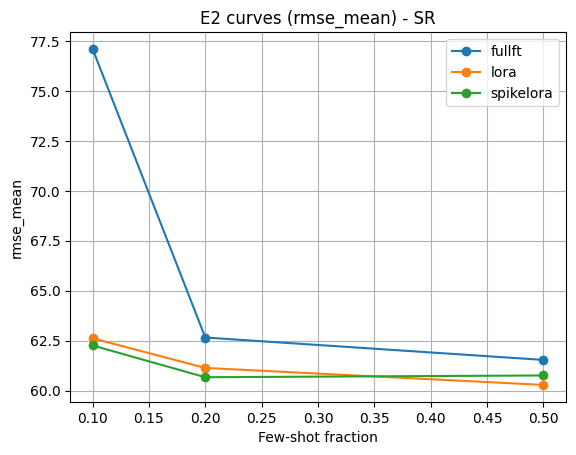

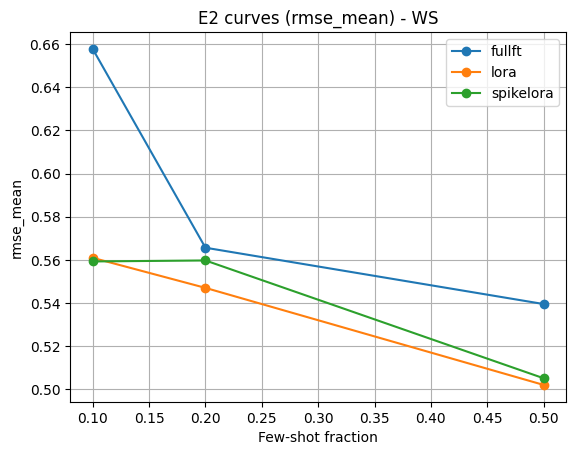

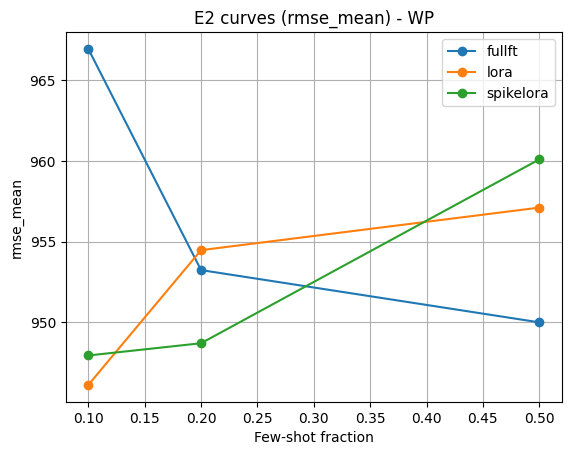

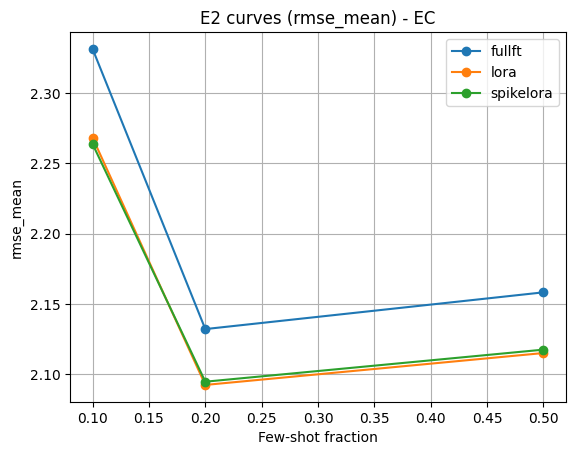

In [ ]:
import matplotlib.pyplot as plt

def plot_e2(task, metric="rmse_mean"):
    sub = E2_summary[E2_summary["task"] == task].copy()
    plt.figure()
    for mode in ["fullft","lora","spikelora"]:
        m = sub[sub["mode"] == mode].sort_values("frac")
        plt.plot(m["frac"], m[metric], marker="o", label=mode)
    plt.xlabel("Few-shot fraction")
    plt.ylabel(metric)
    plt.title(f"E2 curves ({metric}) - {task}")
    plt.grid(True)
    plt.legend()
    plt.show()

for t in ["SR","WS","WP","EC"]:
    plot_e2(t, "rmse_mean")


**E3**

In [ ]:
def _calendar_features_from_datetime(dt_series):
    # dt_series: pandas datetime
    # returns dataframe of calendar features
    import pandas as pd
    out = pd.DataFrame(index=dt_series.index)
    out["hour"] = dt_series.dt.hour
    out["dayofweek"] = dt_series.dt.dayofweek
    out["month"] = dt_series.dt.month
    out["dayofyear"] = dt_series.dt.dayofyear
    return out

def get_feature_cols(df, cfg, add_calendar=True):
    import numpy as np

    time_col = cfg["time_col"]
    target_col = cfg["target_col"]

    # numeric columns only, excluding time and target
    num_cols = [c for c in df.columns
                if c not in [time_col, target_col] and np.issubdtype(df[c].dtype, np.number)]

    # we will optionally append calendar feats later
    base_cols = num_cols.copy()

    if add_calendar:
        # calendar cols are standardized names
        cal_cols = ["hour","dayofweek","month","dayofyear"]
        return base_cols, cal_cols
    else:
        return base_cols, []


✅ Cell E3-F2 — Unionize DF on a column list (Union) + fill missing

In [ ]:
def align_df_to_feature_space(df, cfg, base_cols_union, add_calendar=True):
    import pandas as pd
    import numpy as np

    time_col = cfg["time_col"]
    target_col = cfg["target_col"]

    out = pd.DataFrame(index=df.index)
    out[time_col] = df[time_col]
    out[target_col] = df[target_col]

    # add base cols union (fill missing with 0)
    for c in base_cols_union:
        if c in df.columns:
            out[c] = df[c]
        else:
            out[c] = 0.0

    # add calendar
    if add_calendar:
        dt = pd.to_datetime(out[time_col], errors="coerce")
        cal = _calendar_features_from_datetime(dt)
        for c in cal.columns:
            out[c] = cal[c].astype(float)

    return out


Cell E3-F3 — Supervised windows from DF are “ready”.

This is the same idea as make_supervised, but here we control the feature columns.

In [ ]:
def make_supervised_aligned(df, cfg, lookback, horizons, base_cols_union, add_calendar=True):
    import numpy as np

    time_col = cfg["time_col"]
    target_col = cfg["target_col"]

    # align
    df2 = align_df_to_feature_space(df, cfg, base_cols_union, add_calendar=add_calendar)

    # feature columns order = union + calendar (if enabled)
    feat_cols = list(base_cols_union)
    if add_calendar:
        feat_cols += ["hour","dayofweek","month","dayofyear"]

    X_raw = df2[feat_cols].to_numpy(dtype=np.float32)
    y_raw = df2[target_col].to_numpy(dtype=np.float32)

    L = lookback
    H = horizons
    max_h = max(H)

    Xs, Ys = [], []
    for i in range(L, len(df2) - max_h):
        x_win = X_raw[i-L:i, :]                    # (L,F)
        y_vec = np.array([y_raw[i+h] for h in H], dtype=np.float32)  # (K,)
        Xs.append(x_win)
        Ys.append(y_vec)

    X = np.stack(Xs, axis=0)  # (N,L,F)
    Y = np.stack(Ys, axis=0)  # (N,K)
    return X, Y, feat_cols


✅ Cell E3-F4 — Prepare splits with feature union (instead of assert)




In [ ]:
def prepare_task_splits_E3(task_id, lookback, horizons, base_cols_union, seed=0):
    set_seed(seed)

    df, cfg = load_df(task_id)

    X, Y, feat_cols = make_supervised_aligned(
        df, cfg, lookback, horizons, base_cols_union, add_calendar=True
    )

    (Xtr, Ytr), (Xva, Yva), (Xte, Yte) = chronological_split(X, Y, train_ratio=0.7, val_ratio=0.1)

    # standardize (per-task) like E1/E2:
    Xtr, Xva, Xte, scaler = standardize_fit_transform(Xtr, Xva, Xte)

    F = Xtr.shape[-1]
    K = Ytr.shape[-1]
    return (Xtr, Ytr, Xva, Yva, Xte, Yte), (F, K), feat_cols


✅ Cell E3-F5 — Pretrain multi-task base (Union features)

In [ ]:
def build_union_feature_space(tasks, seed=0):
    """
    Builds UNION of numeric feature columns across given tasks (excluding time/target),
    and uses fixed calendar cols.
    """
    base_union = []
    base_union_set = set()

    for t in tasks:
        df, cfg = load_df(t)
        base_cols, cal_cols = get_feature_cols(df, cfg, add_calendar=True)
        for c in base_cols:
            if c not in base_union_set:
                base_union_set.add(c)
                base_union.append(c)

    return base_union

def pretrain_multitask_base_E3(source_tasks, lookback, horizons, base_cols_union,
                               seed=0, spkT=8, batch_size=128, max_epochs=30, lr=1e-3):
    set_seed(seed)

    Xtr_all, Ytr_all = [], []
    Xva_all, Yva_all = [], []

    F = K = None

    for t in source_tasks:
        splits, (Ft, Kt), feat_cols = prepare_task_splits_E3(t, lookback, horizons, base_cols_union, seed=seed)
        Xtr, Ytr, Xva, Yva, Xte, Yte = splits

        if F is None:
            F, K = Ft, Kt
        else:
            assert Ft == F and Kt == K, "Still mismatch (should not happen now)"

        Xtr_all.append(Xtr); Ytr_all.append(Ytr)
        Xva_all.append(Xva); Yva_all.append(Yva)

    Xtr_all = np.concatenate(Xtr_all, axis=0)
    Ytr_all = np.concatenate(Ytr_all, axis=0)
    Xva_all = np.concatenate(Xva_all, axis=0)
    Yva_all = np.concatenate(Yva_all, axis=0)

    train_loader = DataLoader(WindowDataset(Xtr_all, Ytr_all), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(WindowDataset(Xva_all, Yva_all), batch_size=batch_size, shuffle=False)

    base = SpikingTCN(F, K, T=spkT).to(device)
    base, stats_pre = fit(base, train_loader, val_loader, max_epochs=max_epochs, lr=lr)

    base_state = {k: v.detach().cpu().clone() for k, v in base.state_dict().items()}
    return base_state, (F, K), stats_pre


✅ Cell E3-F6 — Run E3 target (SR only) after repair

In [ ]:
def run_E3_one_target_E3(target_task, source_tasks, lookback, horizons,
                         seed=0, spkT=8, batch_size=128,
                         pretrain_epochs=30, adapt_epochs=20,
                         lr_full=1e-3, lr_fullft=1e-3, lr_peft=5e-3,
                         r=8, alpha=16, Vtheta=0.05,
                         fractions=(0.1, 0.2, 0.5)):

    # union feature space built from SOURCES (foundation pretrain world)
    base_cols_union = build_union_feature_space(source_tasks, seed=seed)

    # 1) pretrain on sources (aligned)
    base_state, (F,K), pre_stats = pretrain_multitask_base_E3(
        source_tasks, lookback, horizons, base_cols_union,
        seed=seed, spkT=spkT, batch_size=batch_size,
        max_epochs=pretrain_epochs, lr=lr_full
    )

    # 2) prepare target splits with SAME union feature space (missing filled)
    (Xtr, Ytr, Xva, Yva, Xte, Yte), (Ft, Kt), feat_cols = prepare_task_splits_E3(
        target_task, lookback, horizons, base_cols_union, seed=seed
    )
    assert Ft == F and Kt == K

    results = []
    for frac in fractions:
        train_loader, val_loader, test_loader, n_fs = make_fewshot_loaders(
            Xtr, Ytr, Xva, Yva, Xte, Yte, frac, batch_size
        )

        out_full = adapt_and_eval(base_state, F, K, spkT, "fullft",
                                  (train_loader, val_loader, test_loader),
                                  adapt_epochs=adapt_epochs, lr_adapt=lr_fullft)
        out_full.update({"E":"E3","target":target_task,"sources":"+".join(source_tasks),
                         "seed":seed,"frac":frac,"n_train_windows":n_fs,"mode":"fullft",
                         "pretrain_time_sec":pre_stats["train_time_sec"]})
        results.append(out_full)

        out_lora = adapt_and_eval(base_state, F, K, spkT, "lora",
                                  (train_loader, val_loader, test_loader),
                                  r=r, alpha=alpha, Vtheta=Vtheta,
                                  adapt_epochs=adapt_epochs, lr_adapt=lr_peft)
        out_lora.update({"E":"E3","target":target_task,"sources":"+".join(source_tasks),
                         "seed":seed,"frac":frac,"n_train_windows":n_fs,"mode":"lora",
                         "pretrain_time_sec":pre_stats["train_time_sec"]})
        results.append(out_lora)

        out_sp = adapt_and_eval(base_state, F, K, spkT, "spikelora",
                                (train_loader, val_loader, test_loader),
                                r=r, alpha=alpha, Vtheta=Vtheta,
                                adapt_epochs=adapt_epochs, lr_adapt=lr_peft)
        out_sp.update({"E":"E3","target":target_task,"sources":"+".join(source_tasks),
                       "seed":seed,"frac":frac,"n_train_windows":n_fs,"mode":"spikelora",
                       "pretrain_time_sec":pre_stats["train_time_sec"]})
        results.append(out_sp)

        print(f"[E3] target={target_task} seed={seed} frac={frac} | "
              f"fullft {out_full['test_rmse']:.3f} | "
              f"lora {out_lora['test_rmse']:.3f} | "
              f"spike {out_sp['test_rmse']:.3f} spars={out_sp['spikelora_sparsity_pct']}")

    return results




✅ Now only run E3 on SR

In [ ]:
lookback = 96
horizons = [1,2,4,8,24]
spkT = 8
E3_SR_fast = run_E3_one_target_E3(
    target_task="SR",
    source_tasks=["WS","WP","EC"],
    lookback=lookback,
    horizons=horizons,
    seed=0,
    spkT=spkT,
    pretrain_epochs=10,   # faster
    adapt_epochs=10,      # faster
    r=8, alpha=16, Vtheta=0.05,
    fractions=(0.1, 0.2)  # faster sanity
)
pd.DataFrame(E3_SR_fast)



=== Dataset WS ===
Path: Palestine-wind.csv
Time column: date
Target variable: Wind Speed

=== Dataset WP ===
Path: Turky-Wind-power-Turbine.csv
Time column: date
Target variable: LV ActivePower (kW)

=== Dataset EC ===
Path: Moroco-power-consumption.csv
Time column: Datetime
Target variable: WindSpeed

=== Dataset WS ===
Path: Palestine-wind.csv
Time column: date
Target variable: Wind Speed

=== Dataset WP ===
Path: Turky-Wind-power-Turbine.csv
Time column: date
Target variable: LV ActivePower (kW)

=== Dataset EC ===
Path: Moroco-power-consumption.csv
Time column: Datetime
Target variable: WindSpeed


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


[E3] target=SR seed=0 frac=0.1 | fullft 272.270 | lora 335.640 | spike 334.809 spars=50.0
[E3] target=SR seed=0 frac=0.2 | fullft 187.143 | lora 316.531 | spike 316.584 spars=40.625


,test_rmse,test_mae,test_smape,train_time_sec,trainable_params,total_params,trainable_ratio,spikelora_sparsity_pct,E,target,sources,seed,frac,n_train_windows,mode,pretrain_time_sec
0,272.270416,201.070679,139.172577,34.562871,75781,75781,1.000000,,E3,SR,WS+WP+EC,0,0.1,7350,fullft,461.508795
1,335.640350,246.692184,154.159363,25.085013,877,76333,0.011489,,E3,SR,WS+WP+EC,0,0.1,7350,lora,461.508795
2,334.809387,246.496918,153.465683,30.990398,877,76333,0.011489,50.0,E3,SR,WS+WP+EC,0,0.1,7350,spikelora,461.508795
3,187.142700,137.835175,126.545044,55.550894,75781,75781,1.000000,,E3,SR,WS+WP+EC,0,0.2,14700,fullft,461.508795
4,316.530823,255.211060,144.866318,36.938064,877,76333,0.011489,,E3,SR,WS+WP+EC,0,0.2,14700,lora,461.508795
5,316.583740,254.587280,144.851227,46.302697,877,76333,0.011489,40.625,E3,SR,WS+WP+EC,0,0.2,14700,spikelora,461.508795


✅ After the success of SR: E3 on the four datasets (leave-one-task-out)




In [ ]:
tasks = ["SR","WS","WP","EC"]
seeds = [0,1,2]
fractions = (0.1,0.2,0.5)

E3_all = []
for target in tasks:
    sources = [t for t in tasks if t != target]
    for seed in seeds:
        out = run_E3_one_target_E3(
            target_task=target,
            source_tasks=sources,
            lookback=lookback,
            horizons=horizons,
            seed=seed,
            spkT=spkT,
            pretrain_epochs=30,
            adapt_epochs=20,
            r=8, alpha=16, Vtheta=0.05,
            fractions=fractions
        )
        E3_all.extend(out)

E3_df = pd.DataFrame(E3_all)
E3_df.to_csv("E3_leave_one_task_out_aligned.csv", index=False)
E3_df.head()


Full Summary for E3 (mean±std)

In [ ]:
E3_summary = (E3_df
              .groupby(["target","mode","frac"])
              .agg(
                  rmse_mean=("test_rmse","mean"),
                  rmse_std=("test_rmse","std"),
                  mae_mean=("test_mae","mean"),
                  mae_std=("test_mae","std"),
                  smape_mean=("test_smape","mean"),
                  smape_std=("test_smape","std"),
                  trainable_ratio_mean=("trainable_ratio","mean"),
              )
              .reset_index())
E3_summary


Drawing Curves for each target

In [ ]:
import matplotlib.pyplot as plt

def plot_e3(target, metric="rmse_mean"):
    sub = E3_summary[E3_summary["target"] == target].copy()
    plt.figure()
    for mode in ["fullft","lora","spikelora"]:
        m = sub[sub["mode"] == mode].sort_values("frac")
        plt.plot(m["frac"], m[metric], marker="o", label=mode)
    plt.xlabel("Few-shot fraction")
    plt.ylabel(metric)
    plt.title(f"E3 Leave-one-task-out transfer - target={target}")
    plt.grid(True)
    plt.legend()
    plt.show()

for t in tasks:
    plot_e3(t, "rmse_mean")


Enhanced E3 (within-domain transfer),



1) We create Union features between WS and SR (except time/target)



In [ ]:
1) We create Union features between WS and SR (except time/target)

Cell E3’-1 — Adapt on Target (SR أو WP)





In [ ]:
def build_union_feature_space_two_tasks(task_a, task_b):
    df_a, cfg_a = load_df(task_a)
    df_b, cfg_b = load_df(task_b)

    base_a, _ = get_feature_cols(df_a, cfg_a, add_calendar=True)
    base_b, _ = get_feature_cols(df_b, cfg_b, add_calendar=True)

    union = []
    seen = set()
    for c in base_a + base_b:
        if c not in seen:
            seen.add(c)
            union.append(c)
    return union


2) Pretrain on WS but using the union feature space



In [ ]:
def pretrain_base_single_task_aligned(task_id, lookback, horizons, base_cols_union,
                                      seed=0, spkT=8, batch_size=128,
                                      max_epochs=20, lr=1e-3):
    set_seed(seed)

    df, cfg = load_df(task_id)
    X, Y, feat_cols = make_supervised_aligned(
        df, cfg, lookback, horizons, base_cols_union, add_calendar=True
    )
    (Xtr, Ytr), (Xva, Yva), (Xte, Yte) = chronological_split(X, Y, 0.7, 0.1)
    Xtr, Xva, Xte, _ = standardize_fit_transform(Xtr, Xva, Xte)

    train_loader = DataLoader(WindowDataset(Xtr, Ytr), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(WindowDataset(Xva, Yva), batch_size=batch_size, shuffle=False)

    F = Xtr.shape[-1]
    K = Ytr.shape[-1]

    base = SpikingTCN(F, K, T=spkT).to(device)
    base, stats = fit(base, train_loader, val_loader, max_epochs=max_epochs, lr=lr)

    base_state = {k: v.detach().cpu().clone() for k, v in base.state_dict().items()}
    return base_state, (F, K), stats


3) Run E3’ aligned (WS→SR أو WS→WP)

In [ ]:
def run_E3_prime_aligned(source_task, target_task,
                         lookback, horizons,
                         seed=0, spkT=8,
                         fractions=(0.1, 0.2, 0.5),
                         pretrain_epochs=20, adapt_epochs=15,
                         lr_full=1e-3, lr_fullft=1e-3, lr_peft=5e-3,
                         r=8, alpha=16, Vtheta=0.05,
                         batch_size=128):

    # build union feature space between the 2 tasks
    base_cols_union = build_union_feature_space_two_tasks(source_task, target_task)

    # Stage A: pretrain on source with aligned feature space
    base_state, (F, K), pre_stats = pretrain_base_single_task_aligned(
        source_task, lookback, horizons, base_cols_union,
        seed=seed, spkT=spkT, batch_size=batch_size,
        max_epochs=pretrain_epochs, lr=lr_full
    )

    # Stage B: prepare target splits (aligned)
    df_t, cfg_t = load_df(target_task)
    X, Y, feat_cols = make_supervised_aligned(
        df_t, cfg_t, lookback, horizons, base_cols_union, add_calendar=True
    )
    (Xtr, Ytr), (Xva, Yva), (Xte, Yte) = chronological_split(X, Y, 0.7, 0.1)
    Xtr, Xva, Xte, _ = standardize_fit_transform(Xtr, Xva, Xte)

    results = []
    for frac in fractions:
        train_loader, val_loader, test_loader, n_fs = make_fewshot_loaders(
            Xtr, Ytr, Xva, Yva, Xte, Yte,
            frac=frac, batch_size=batch_size
        )

        out_full = adapt_and_eval(
            base_state, F, K, spkT, "fullft",
            (train_loader, val_loader, test_loader),
            adapt_epochs=adapt_epochs, lr_adapt=lr_fullft
        )
        out_full.update({"E":"E3-prime","source":source_task,"target":target_task,
                         "seed":seed,"frac":frac,"n_train_windows":n_fs,"mode":"fullft",
                         "pretrain_time_sec": pre_stats["train_time_sec"]})
        results.append(out_full)

        out_lora = adapt_and_eval(
            base_state, F, K, spkT, "lora",
            (train_loader, val_loader, test_loader),
            r=r, alpha=alpha, Vtheta=Vtheta,
            adapt_epochs=adapt_epochs, lr_adapt=lr_peft
        )
        out_lora.update({"E":"E3-prime","source":source_task,"target":target_task,
                         "seed":seed,"frac":frac,"n_train_windows":n_fs,"mode":"lora",
                         "pretrain_time_sec": pre_stats["train_time_sec"]})
        results.append(out_lora)

        out_sp = adapt_and_eval(
            base_state, F, K, spkT, "spikelora",
            (train_loader, val_loader, test_loader),
            r=r, alpha=alpha, Vtheta=Vtheta,
            adapt_epochs=adapt_epochs, lr_adapt=lr_peft
        )
        out_sp.update({"E":"E3-prime","source":source_task,"target":target_task,
                       "seed":seed,"frac":frac,"n_train_windows":n_fs,"mode":"spikelora",
                       "pretrain_time_sec": pre_stats["train_time_sec"]})
        results.append(out_sp)

        print(f"[E3’ aligned] {source_task}->{target_task} seed={seed} frac={frac} | "
              f"fullFT {out_full['test_rmse']:.3f} | "
              f"lora {out_lora['test_rmse']:.3f} | "
              f"spike {out_sp['test_rmse']:.3f} spars={out_sp['spikelora_sparsity_pct']}")

    return results


✅ Now run WS → SR (after repair)




In [ ]:
lookback = 96
horizons = [1,2,4,8,24]
spkT = 8

E3p_SR = run_E3_prime_aligned(
    source_task="WS",
    target_task="SR",
    lookback=lookback,
    horizons=horizons,
    seed=0,
    spkT=spkT,
    fractions=(0.1, 0.2, 0.5),
    pretrain_epochs=20,
    adapt_epochs=15,
    r=8, alpha=16, Vtheta=0.05
)

pd.DataFrame(E3p_SR)



=== Dataset WS ===
Path: Palestine-wind.csv
Time column: date
Target variable: Wind Speed

=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI

=== Dataset WS ===
Path: Palestine-wind.csv
Time column: date
Target variable: Wind Speed


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



=== Dataset SR ===
Path: Palestine-Solar.csv
Time column: date
Target variable: GHI


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


[E3’ aligned] WS->SR seed=0 frac=0.1 | fullFT 212.331 | lora 273.219 | spike 271.137 spars=0.0
[E3’ aligned] WS->SR seed=0 frac=0.2 | fullFT 125.395 | lora 223.524 | spike 209.843 spars=0.0
[E3’ aligned] WS->SR seed=0 frac=0.5 | fullFT 86.245 | lora 172.346 | spike 168.125 spars=46.875


,test_rmse,test_mae,test_smape,train_time_sec,trainable_params,total_params,trainable_ratio,spikelora_sparsity_pct,E,source,target,seed,frac,n_train_windows,mode,pretrain_time_sec
0,212.330811,130.902664,137.620056,50.999700,75653,75653,1.000000,,E3-prime,WS,SR,0,0.1,7350,fullft,456.92432
1,273.219421,203.718842,140.193161,37.901610,877,76205,0.011508,,E3-prime,WS,SR,0,0.1,7350,lora,456.92432
2,271.137115,200.230042,140.017212,46.788348,877,76205,0.011508,0.0,E3-prime,WS,SR,0,0.1,7350,spikelora,456.92432
3,125.395233,83.342270,120.917976,84.281025,75653,75653,1.000000,,E3-prime,WS,SR,0,0.2,14700,fullft,456.92432
4,223.524368,165.946075,130.345718,55.850820,877,76205,0.011508,,E3-prime,WS,SR,0,0.2,14700,lora,456.92432
5,209.842987,157.874969,128.760452,70.270101,877,76205,0.011508,0.0,E3-prime,WS,SR,0,0.2,14700,spikelora,456.92432
6,86.244820,51.986248,114.219925,184.898843,75653,75653,1.000000,,E3-prime,WS,SR,0,0.5,36750,fullft,456.92432
7,172.345596,128.868881,125.095711,111.432906,877,76205,0.011508,,E3-prime,WS,SR,0,0.5,36750,lora,456.92432
8,168.124832,120.838829,125.242844,141.478025,877,76205,0.011508,46.875,E3-prime,WS,SR,0,0.5,36750,spikelora,456.92432


✅ WS → WP (This often gives a better transfer)

In [ ]:
E3p_WP = run_E3_prime_aligned(
    source_task="WS",
    target_task="WP",
    lookback=lookback,
    horizons=horizons,
    seed=0,
    spkT=spkT,
    fractions=(0.1, 0.2, 0.5),
    pretrain_epochs=20,
    adapt_epochs=15,
    r=8, alpha=16, Vtheta=0.05
)

pd.DataFrame(E3p_WP)



=== Dataset WS ===
Path: Palestine-wind.csv
Time column: date
Target variable: Wind Speed

=== Dataset WP ===
Path: Turky-Wind-power-Turbine.csv
Time column: date
Target variable: LV ActivePower (kW)

=== Dataset WS ===
Path: Palestine-wind.csv
Time column: date
Target variable: Wind Speed


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



=== Dataset WP ===
Path: Turky-Wind-power-Turbine.csv
Time column: date
Target variable: LV ActivePower (kW)


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


[E3’ aligned] WS->WP seed=0 frac=0.1 | fullFT 1113.774 | lora 1356.077 | spike 1396.519 spars=50.0
[E3’ aligned] WS->WP seed=0 frac=0.2 | fullFT 1039.643 | lora 1351.162 | spike 1351.302 spars=37.5
[E3’ aligned] WS->WP seed=0 frac=0.5 | fullFT 1046.032 | lora 1353.701 | spike 1354.095 spars=25.0


,test_rmse,test_mae,test_smape,train_time_sec,trainable_params,total_params,trainable_ratio,spikelora_sparsity_pct,E,source,target,seed,frac,n_train_windows,mode,pretrain_time_sec
0,1113.773926,863.168396,94.112633,24.842329,75653,75653,1.000000,,E3-prime,WS,WP,0,0.1,3528,fullft,394.209621
1,1356.076904,1188.276489,100.183960,18.286727,877,76205,0.011508,,E3-prime,WS,WP,0,0.1,3528,lora,394.209621
2,1396.519287,1172.577148,103.438271,22.462782,877,76205,0.011508,50.0,E3-prime,WS,WP,0,0.1,3528,spikelora,394.209621
3,1039.643066,822.377686,89.543983,40.895697,75653,75653,1.000000,,E3-prime,WS,WP,0,0.2,7057,fullft,394.209621
4,1351.161743,1202.118774,99.191353,27.166716,877,76205,0.011508,,E3-prime,WS,WP,0,0.2,7057,lora,394.209621
5,1351.302368,1201.730469,99.222626,34.456673,877,76205,0.011508,37.5,E3-prime,WS,WP,0,0.2,7057,spikelora,394.209621
6,1046.031616,823.216492,87.615547,88.309229,75653,75653,1.000000,,E3-prime,WS,WP,0,0.5,17643,fullft,394.209621
7,1353.701294,1185.286133,100.128960,53.668008,877,76205,0.011508,,E3-prime,WS,WP,0,0.5,17643,lora,394.209621
8,1354.095093,1186.355591,100.115860,67.241993,877,76205,0.011508,25.0,E3-prime,WS,WP,0,0.5,17643,spikelora,394.209621
